## Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data splitting
from sklearn.model_selection import train_test_split

# Baseline model
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Evaluation metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss
)

# LightGBM
import lightgbm as lgb
from lightgbm import early_stopping

print("Libraries Import Successfully")

Libraries Import Successfully


## Load Dataset

In [50]:
df = pd.read_csv('../data/processed/clean_credit.csv')

print("Dataset Shape:", df.shape)

print("\nDefault Distribution:")
print(df['Default'].value_counts())

print("\nDefault Rate:")
print(df['Default'].value_counts(normalize=True).round(4))

df.head()

Dataset Shape: (150000, 12)

Default Distribution:
Default
0    139974
1     10026
Name: count, dtype: int64

Default Rate:
Default
0    0.9332
1    0.0668
Name: proportion, dtype: float64


,ID,Default,CreditUtilization,Age,Late30-59DaysPastDue,DebtRatio,MonthlyIncome,OpenCreditLines,Late90DaysPastDue,RealEstateLoans,Late60-89DaysPastDue,Dependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [51]:
late_cols = [
    'Late30-59DaysPastDue',
    'Late60-89DaysPastDue',
    'Late90DaysPastDue'
]

# 96 and 98 are special codes, not genuine delinquency counts
for col in late_cols:
    df.loc[df[col] >= 90, col] = np.nan

print("Invalid delinquency codes handled")

Invalid delinquency codes handled


## Feature Engineering

In [ ]:
# Total number of recent delinquency events
df['TotalLate'] = (
    df['Late30-59DaysPastDue'] + df['Late60-89DaysPastDue'] + df['Late90DaysPastDue']
)

# Monthly income relative to number of dependents
df['IncomePerPerson'] = (
    df['MonthlyIncome'] / (df['Dependents'] + 1)
)

#  Whether the borrower has any real estate loan |
# df['HasRealEstate'] = (                        |
    # df['RealEstateLoans'] > 0                  |
# ).astype(int)                                  | --> doest improve anything 

print("New features:")
print([
    'TotalLate',
    'IncomePerPerson'
    # 'HasRealEstate',
])

New features:
['TotalLate', 'IncomePerPerson']


### Features & Target

In [53]:
TARGET = 'Default'
ID = 'ID'

X = df.drop(columns=[TARGET, ID])
y = df[TARGET]

print("Features used:\n", X.columns.tolist())

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features used:
 ['CreditUtilization', 'Age', 'Late30-59DaysPastDue', 'DebtRatio', 'MonthlyIncome', 'OpenCreditLines', 'Late90DaysPastDue', 'RealEstateLoans', 'Late60-89DaysPastDue', 'Dependents', 'TotalLate', 'IncomePerPerson']

X shape: (150000, 12)
y shape: (150000,)


## Train / Validation / Test Split

In [54]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    stratify=y,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.1765,
    stratify=y_temp,
    random_state=42
)

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Testing:", X_test.shape, y_test.shape)

print("\nDefault Rate:")
print("Overall:    ", round(y.mean(), 4))
print("Training:   ", round(y_train.mean(), 4))
print("Validation: ", round(y_val.mean(), 4))
print("Testing:    ", round(y_test.mean(), 4))

Training: (104996, 12) (104996,)
Validation: (22504, 12) (22504,)
Testing: (22500, 12) (22500,)

Default Rate:
Overall:     0.0668
Training:    0.0668
Validation:  0.0668
Testing:     0.0668


## Baseline Model - Logistic Regression

In [55]:
baseline_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

baseline_model.fit(X_train, y_train)

# print("Baseline Logistic Regression trained successfully")

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['CreditUtilization','Age','Late30-59DaysPastDue',...,'Dependents', 'TotalLate','IncomePerPerson']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_

### Baseline Model Metrics

In [56]:
baseline_val_prob = baseline_model.predict_proba(X_val)[:, 1]

baseline_val_roc = roc_auc_score(y_val, baseline_val_prob)
baseline_val_pr = average_precision_score(y_val, baseline_val_prob)
baseline_val_logloss = log_loss(y_val, baseline_val_prob)
baseline_val_brier = brier_score_loss(y_val, baseline_val_prob)

print("Baseline Validation Results")
print("-"*30)

print("ROC-AUC:", round(baseline_val_roc, 4))
print("PR-AUC:", round(baseline_val_pr, 4))
print("Log Loss:", round(baseline_val_logloss, 4))
print("Brier:", round(baseline_val_brier, 4))

Baseline Validation Results
------------------------------
ROC-AUC: 0.815
PR-AUC: 0.3659
Log Loss: 0.1971
Brier: 0.0522


## LightGBM Baseline

In [57]:
lgb_baseline = lgb.LGBMClassifier(
    objective='binary',
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_baseline.fit(
    X_test, y_test,
    eval_X=X_val,
    eval_y=y_val,
    eval_metric='auc',
    callbacks=[
        early_stopping(stopping_rounds=50, verbose=False)
    ]
)

print("Best Iteration:", lgb_baseline.best_iteration_)

Best Iteration: 52


### LightGBM Baseline Metrics

In [58]:
lgb_baseline_val_prob = lgb_baseline.predict_proba(X_val)[:, 1]

lgb_baseline_roc = roc_auc_score(y_val, lgb_baseline_val_prob)
lgb_baseline_pr = average_precision_score(y_val, lgb_baseline_val_prob)
lgb_baseline_logloss = log_loss(y_val, lgb_baseline_val_prob)
lgb_baseline_brier = brier_score_loss(y_val, lgb_baseline_val_prob)

print("LightGBM Baseline - Validation")
print("-"*30)

print("ROC-AUC:", round(lgb_baseline_roc, 4))
print("PR-AUC:", round(lgb_baseline_pr, 4))
print("Log Loss:", round(lgb_baseline_logloss, 4))
print("Brier:", round(lgb_baseline_brier, 4))

LightGBM Baseline - Validation
------------------------------
ROC-AUC: 0.8681
PR-AUC: 0.4132
Log Loss: 0.1768
Brier: 0.0487


## LightGBM Hyperparameter Tuning

### Tune `num_leaves`

In [59]:
def leaves_tuning(leaves):
    result = []

    for i in leaves:
        model = lgb.LGBMClassifier(
            objective='binary',
            n_estimators=1000,
            learning_rate=0.05,
            num_leaves=i,
            max_depth=-1,
            random_state=42,
            n_jobs=-1,
            verbose=-1
        )

        model.fit(
            X_train,
            y_train,
            eval_X=X_val,
            eval_y=y_val,
            eval_metric='auc',
            callbacks=[
                early_stopping(
                    stopping_rounds=50,
                    verbose=False
                )
            ]
        )

        val_prob = model.predict_proba(X_val)[:, 1]

        roc = roc_auc_score(y_val, val_prob)
        pr = average_precision_score(y_val, val_prob)

        result.append({
            "num_leaves": i,
            "best_iteration": model.best_iteration_,
            "roc_auc": roc,
            "pr_auc": pr
        })

    return result

leaves_results = leaves_tuning([7, 15, 31, 63]) # Best --> 7
leaves_df = pd.DataFrame(leaves_results)

print(leaves_df.round(4))

   num_leaves  best_iteration  roc_auc  pr_auc
0           7             134   0.8710  0.4131
1          15             121   0.8714  0.4111
2          31              74   0.8701  0.4095
3          63              51   0.8695  0.4094


### Tune `learning_rate`

In [60]:
def learning_rate_tuning(rates):
    result = []

    for rate in rates:
        model = lgb.LGBMClassifier(
            objective='binary',
            n_estimators=1000,
            learning_rate=rate,
            num_leaves=7,
            max_depth=-1,
            random_state=42,
            n_jobs=-1,
            verbose=-1
        )

        model.fit(
            X_train,
            y_train,
            eval_X=X_val, 
            eval_y=y_val,
            eval_metric='auc',
            callbacks=[
                early_stopping(
                    stopping_rounds=50,
                    verbose=False
                )
            ]
        )

        val_prob = model.predict_proba(X_val)[:, 1]

        roc = roc_auc_score(y_val, val_prob)
        pr = average_precision_score(y_val, val_prob)

        result.append({
            "learning_rate": rate,
            "best_iteration": model.best_iteration_,
            "roc_auc": roc,
            "pr_auc": pr
        })

    return result

learning_rate_results = learning_rate_tuning([0.01, 0.03, 0.05, 0.10]) # Best --> 0.03
learning_rate_df = pd.DataFrame(learning_rate_results)

print(learning_rate_df.round(4))

   learning_rate  best_iteration  roc_auc  pr_auc
0           0.01             825   0.8715  0.4130
1           0.03             268   0.8713  0.4147
2           0.05             134   0.8710  0.4131
3           0.10              76   0.8710  0.4124


### Tune `min_child_samples`

In [61]:
def min_child_tuning(values):
    result = []

    for value in values:
        model = lgb.LGBMClassifier(
            objective='binary',
            n_estimators=1000,
            learning_rate=0.03,
            num_leaves=7,
            min_child_samples=value,
            max_depth=-1,
            random_state=42,
            n_jobs=-1,
            verbose=-1
        )

        model.fit(
            X_train,
            y_train,
            eval_X=X_val,
            eval_y=y_val,
            eval_metric='auc',
            callbacks=[
                early_stopping(
                    stopping_rounds=50,
                    verbose=False
                )
            ]
        )

        val_prob = model.predict_proba(X_val)[:, 1]

        roc = roc_auc_score(y_val, val_prob)
        pr = average_precision_score(y_val, val_prob)

        result.append({
            "min_child_samples": value,
            "best_iteration": model.best_iteration_,
            "roc_auc": roc,
            "pr_auc": pr
        })

    return result


min_child_results = min_child_tuning([10, 20, 40, 60, 100]) # Best --> 20
min_child_df = pd.DataFrame(min_child_results)

print(min_child_df.round(4))

   min_child_samples  best_iteration  roc_auc  pr_auc
0                 10             253   0.8712  0.4131
1                 20             268   0.8713  0.4147
2                 40             264   0.8715  0.4140
3                 60             270   0.8714  0.4131
4                100             251   0.8713  0.4136


### Tune `reg_lambda`/?

In [62]:
def lambda_tuning(values):
    result = []

    for value in values:
        model = lgb.LGBMClassifier(
            objective='binary',
            n_estimators=1000,
            learning_rate=0.03,
            num_leaves=7,
            min_child_samples=20,
            reg_lambda=value,
            max_depth=-1,
            random_state=42,
            n_jobs=-1,
            verbose=-1
        )

        model.fit(
            X_train,
            y_train,
            eval_X=X_val,
            eval_y=y_val,
            eval_metric='auc',
            callbacks=[
                early_stopping(
                    stopping_rounds=50,
                    verbose=False
                )
            ]
        )

        val_prob = model.predict_proba(X_val)[:, 1]

        result.append({
            "reg_lambda": value,
            "best_iteration": model.best_iteration_,
            "roc_auc": roc_auc_score(y_val, val_prob),
            "pr_auc": average_precision_score(y_val, val_prob)
        })

    return result


lambda_results = lambda_tuning([0, 0.1, 1, 5, 10])
lambda_df = pd.DataFrame(lambda_results)

print(lambda_df.round(4))

   reg_lambda  best_iteration  roc_auc  pr_auc
0         0.0             268   0.8713  0.4147
1         0.1             288   0.8715  0.4131
2         1.0             265   0.8714  0.4127
3         5.0             272   0.8714  0.4125
4        10.0             292   0.8714  0.4137


### Tune `reg_alpha`/?

In [63]:
def alpha_tuning(values):
    result = []

    for value in values:
        model = lgb.LGBMClassifier(
            objective='binary',
            n_estimators=1000,
            learning_rate=0.03,
            num_leaves=7,
            min_child_samples=20,
            reg_alpha=value,
            reg_lambda=0,
            max_depth=-1,
            random_state=42,
            n_jobs=-1,
            verbose=-1
        )

        model.fit(
            X_train,
            y_train,
            eval_X=X_val, 
            eval_y=y_val,
            eval_metric='auc',
            callbacks=[
                early_stopping(
                    stopping_rounds=50,
                    verbose=False
                )
            ]
        )

        val_prob = model.predict_proba(X_val)[:, 1]

        result.append({
            "reg_alpha": value,
            "best_iteration": model.best_iteration_,
            "roc_auc": roc_auc_score(y_val, val_prob),
            "pr_auc": average_precision_score(y_val, val_prob)
        })

    return result


alpha_results = alpha_tuning([0, 0.1, 0.5, 1, 5])
alpha_df = pd.DataFrame(alpha_results)

print(alpha_df.round(4))

   reg_alpha  best_iteration  roc_auc  pr_auc
0        0.0             268   0.8713  0.4147
1        0.1             263   0.8715  0.4143
2        0.5             251   0.8715  0.4130
3        1.0             264   0.8714  0.4138
4        5.0             284   0.8717  0.4125


### Tune `scale_pos_weight`/?

In [64]:
def scale_pos_weight_tuning(values):
    result = []

    for value in values:
        model = lgb.LGBMClassifier(
            objective='binary',
            n_estimators=1000,
            learning_rate=0.03,
            num_leaves=7,
            min_child_samples=20,
            reg_alpha=0,
            reg_lambda=0,
            scale_pos_weight=value,
            max_depth=-1,
            random_state=42,
            n_jobs=-1,
            verbose=-1
        )

        model.fit(
            X_train,
            y_train,
            eval_X=X_val,
            eval_y=y_val,
            eval_metric='auc',
            callbacks=[
                early_stopping(
                    stopping_rounds=50,
                    verbose=False
                )
            ]
        )

        val_prob = model.predict_proba(X_val)[:, 1]

        result.append({
            "scale_pos_weight": value,
            "best_iteration": model.best_iteration_,
            "roc_auc": roc_auc_score(y_val, val_prob),
            "pr_auc": average_precision_score(y_val, val_prob)
        })

    return result


scale_results = scale_pos_weight_tuning([1, 3, 5, 7, 9, 12])
scale_df = pd.DataFrame(scale_results)

print(scale_df.round(4))

   scale_pos_weight  best_iteration  roc_auc  pr_auc
0                 1             268   0.8713  0.4147
1                 3              25   0.8592  0.3691
2                 5              12   0.8557  0.3592
3                 7               8   0.8574  0.3528
4                 9               7   0.8597  0.3542
5                12               5   0.8586  0.3489


### Tune `max_depth`

In [65]:
def max_depth_tuning(values):
    result = []

    for depth in values:
        model = lgb.LGBMClassifier(
            objective='binary',
            n_estimators=1000,
            learning_rate=0.03,
            num_leaves=7,
            min_child_samples=20,
            reg_alpha=0,
            reg_lambda=0,
            scale_pos_weight=1,
            max_depth=depth,
            random_state=42,
            n_jobs=-1,
            verbose=-1
        )

        model.fit(
            X_train,
            y_train,
            eval_X=X_val,
            eval_y=y_val,
            eval_metric='auc',
            callbacks=[
                early_stopping(
                    stopping_rounds=50,
                    verbose=False
                )
            ]
        )

        val_prob = model.predict_proba(X_val)[:, 1]

        result.append({
            "max_depth": depth,
            "best_iteration": model.best_iteration_,
            "roc_auc": roc_auc_score(y_val, val_prob),
            "pr_auc": average_precision_score(y_val, val_prob)
        })

    return result


depth_results = max_depth_tuning([3, 4, 5, 6, 8, -1])  # Best --> 4
depth_df = pd.DataFrame(depth_results)
print(depth_df.round(4))

   max_depth  best_iteration  roc_auc  pr_auc
0          3             325   0.8712  0.4104
1          4             265   0.8714  0.4151
2          5             259   0.8712  0.4132
3          6             268   0.8713  0.4147
4          8             268   0.8713  0.4147
5         -1             268   0.8713  0.4147


### Tune `subsample`/?

In [66]:
def subsample_tuning(values):
    result = []

    for value in values:
        model = lgb.LGBMClassifier(
            objective='binary',
            n_estimators=1000,
            learning_rate=0.03,
            num_leaves=7,
            min_child_samples=20,
            reg_alpha=0,
            reg_lambda=0,
            scale_pos_weight=1,
            max_depth=4,
            subsample=value,
            random_state=42,
            n_jobs=-1,
            verbose=-1
        )

        model.fit(
            X_train,
            y_train,
            eval_X=X_val,
            eval_y=y_val,
            eval_metric='auc',
            callbacks=[
                early_stopping(
                    stopping_rounds=50,
                    verbose=False
                )
            ]
        )

        val_prob = model.predict_proba(X_val)[:, 1]

        result.append({
            "subsample": value,
            "best_iteration": model.best_iteration_,
            "roc_auc": roc_auc_score(y_val, val_prob),
            "pr_auc": average_precision_score(y_val, val_prob)
        })

    return result


subsample_results = subsample_tuning([0.6, 0.7, 0.8, 0.9, 1.0])
subsample_df = pd.DataFrame(subsample_results)

print(subsample_df.round(4))

   subsample  best_iteration  roc_auc  pr_auc
0        0.6             265   0.8714  0.4151
1        0.7             265   0.8714  0.4151
2        0.8             265   0.8714  0.4151
3        0.9             265   0.8714  0.4151
4        1.0             265   0.8714  0.4151


## Final Tuned LightGBM Model

In [67]:
final_model = lgb.LGBMClassifier(
    objective='binary',
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=7,
    max_depth=4,
    min_child_samples=20,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

final_model.fit(
    X_train,
    y_train,
    eval_X=X_val,
    eval_y=y_val,
    eval_metric='auc',
    callbacks=[
        early_stopping(
            stopping_rounds=50,
            verbose=False
        )
    ]
)

print("Final Model Trained Successfully")
print("Best Iteration:", final_model.best_iteration_)

Final Model Trained Successfully
Best Iteration: 265


## Final Validation Evaluation & Threshold Selection

In [68]:

val_prob = final_model.predict_proba(X_val)[:, 1]

val_roc_auc = roc_auc_score(y_val, val_prob)
val_pr_auc = average_precision_score(y_val, val_prob)
val_logloss = log_loss(y_val, val_prob)
val_brier = brier_score_loss(y_val, val_prob)

print("Final Tuned LightGBM - Validation Results")
print("-"*30)
print("ROC-AUC :", round(val_roc_auc, 4))
print("PR-AUC  :", round(val_pr_auc, 4))
print("Log Loss:", round(val_logloss, 4))
print("Brier   :", round(val_brier, 4))

Final Tuned LightGBM - Validation Results
------------------------------
ROC-AUC : 0.8714
PR-AUC  : 0.4151
Log Loss: 0.1755
Brier   : 0.0486


In [80]:
def evaluate_threshold(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    specificity = tn / (tn + fp)

    return {
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Specificity": specificity,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }


thresholds = [
    0.10, 0.15, 0.20, 0.25,
    0.30, 0.35, 0.40, 0.45, 0.50
]

threshold_results = [
    evaluate_threshold(y_val, val_prob, threshold)
    for threshold in thresholds
]

threshold_df = pd.DataFrame(threshold_results)

print("Validation Threshold Performance")
print("---------------------------------")
print(threshold_df.round(4).to_string(index=False))

Validation Threshold Performance
---------------------------------
 Threshold  Precision  Recall     F1  Specificity    TN   FP   FN   TP
      0.10     0.2827  0.6855 0.4003       0.8754 18384 2616  473 1031
      0.15     0.3511  0.5791 0.4371       0.9233 19390 1610  633  871
      0.20     0.3959  0.5146 0.4475       0.9438 19819 1181  730  774
      0.25     0.4320  0.4581 0.4447       0.9569 20094  906  815  689
      0.30     0.4679  0.4016 0.4322       0.9673 20313  687  900  604
      0.35     0.5058  0.3491 0.4131       0.9756 20487  513  979  525
      0.40     0.5254  0.2959 0.3786       0.9809 20598  402 1059  445
      0.45     0.5604  0.2500 0.3457       0.9860 20705  295 1128  376
      0.50     0.5972  0.1981 0.2976       0.9904 20799  201 1206  298


In [70]:
best_threshold = threshold_df.loc[
    threshold_df["F1"].idxmax(),
    "Threshold"
]

print("Selected Threshold:", best_threshold) # Best --> 0.2
print(
    "Validation F1:",
    round(
        threshold_df.loc[
            threshold_df["F1"].idxmax(),
            "F1"
        ],
        4
    )
)

Selected Threshold: 0.2
Validation F1: 0.4475


## Final Test Evaluation

In [71]:
test_prob = final_model.predict_proba(X_test)[:, 1]

test_pred_final = (
    test_prob >= best_threshold
).astype(int)

print("Final test predictions generated")
print("Threshold:", best_threshold)

Final test predictions generated
Threshold: 0.2


In [72]:
test_roc_auc = roc_auc_score(y_test, test_prob)
test_pr_auc = average_precision_score(y_test, test_prob)
test_logloss = log_loss(y_test, test_prob)
test_brier = brier_score_loss(y_test, test_prob)

print("Final Test Probability Metrics")
print("-"*30)
print("ROC-AUC :", round(test_roc_auc, 4))
print("PR-AUC  :", round(test_pr_auc, 4))
print("Log Loss:", round(test_logloss, 4))
print("Brier   :", round(test_brier, 4))

Final Test Probability Metrics
------------------------------
ROC-AUC : 0.872
PR-AUC  : 0.4123
Log Loss: 0.1753
Brier   : 0.0485


In [73]:
cm = confusion_matrix(
    y_test,
    test_pred_final
)

tn, fp, fn, tp = cm.ravel()

precision = precision_score(
    y_test,
    test_pred_final,
    zero_division=0
)

recall = recall_score(
    y_test,
    test_pred_final,
    zero_division=0
)

f1 = f1_score(
    y_test,
    test_pred_final,
    zero_division=0
)

specificity = tn / (tn + fp)

print("Final Test Results")
print("------------------")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        test_pred_final,
        digits=4
    )
)

print("Precision:   ", round(precision, 4))
print("Recall:      ", round(recall, 4))
print("F1 Score:    ", round(f1, 4))
print("Specificity: ", round(specificity, 4))

Final Test Results
------------------

Confusion Matrix:
[[19817  1179]
 [  737   767]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9641    0.9438    0.9539     20996
           1     0.3941    0.5100    0.4446      1504

    accuracy                         0.9148     22500
   macro avg     0.6791    0.7269    0.6993     22500
weighted avg     0.9260    0.9148    0.9198     22500

Precision:    0.3941
Recall:       0.51
F1 Score:     0.4446
Specificity:  0.9438


## Probability Calibration/?

In [91]:
from sklearn.linear_model import LogisticRegression

# Fit a sigmoid calibration model using validation predictions
calibrator = LogisticRegression()

calibrator.fit(
    val_prob.reshape(-1, 1),
    y_val
)

# Generate calibrated validation probabilities
calibrated_val_prob = calibrator.predict_proba(
    val_prob.reshape(-1, 1)
)[:, 1]

print("Calibration completed.")

Calibration completed.


In [92]:
before_logloss = log_loss(y_val, val_prob)
before_brier = brier_score_loss(y_val, val_prob)

after_logloss = log_loss(y_val, calibrated_val_prob)
after_brier = brier_score_loss(y_val, calibrated_val_prob)

print("BEFORE CALIBRATION")
print("------------------")
print("Log Loss:", round(before_logloss, 6))
print("Brier Score:", round(before_brier, 6))

print("\nAFTER CALIBRATION")
print("-----------------")
print("Log Loss:", round(after_logloss, 6))
print("Brier Score:", round(after_brier, 6))

BEFORE CALIBRATION
------------------
Log Loss: 0.175503
Brier Score: 0.048616

AFTER CALIBRATION
-----------------
Log Loss: 0.186563
Brier Score: 0.050097


## Feature Importance

In [76]:
importance_features = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Features Importance")
print("-"*30)
print(importance_features.to_string(index=False))

Features Importance
------------------------------
             Feature  Importance
   CreditUtilization         299
                 Age         222
           DebtRatio         199
           TotalLate         191
     OpenCreditLines         152
     RealEstateLoans         140
       MonthlyIncome         133
     IncomePerPerson          85
   Late90DaysPastDue          80
Late60-89DaysPastDue          62
Late30-59DaysPastDue          16
          Dependents          11


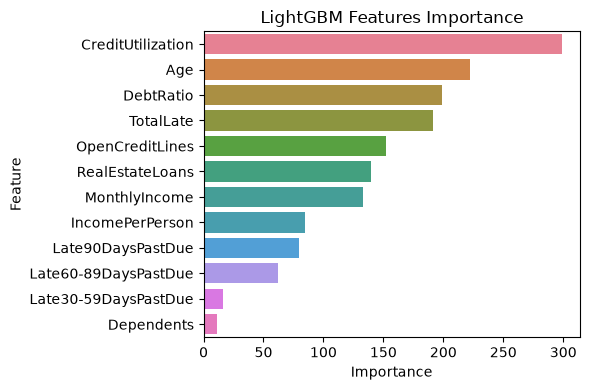

In [77]:
plt.figure(figsize=(6, 4))
sns.barplot(
    data=importance_features,
    x='Importance',
    y='Feature',
    hue='Feature',
    legend=False
)

plt.title("LightGBM Features Importance")
plt.tight_layout()
plt.show()

## SHAP Explainability

In [78]:
import shap

X_shap = X_val.sample(5000, random_state=42)

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_shap)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

print("SHAP values created successfully")

SHAP values created successfully


/Users/pushkarkamat/Desktop/Hybrid-Credit-Risk-Engine/.venv/lib/python3.14/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


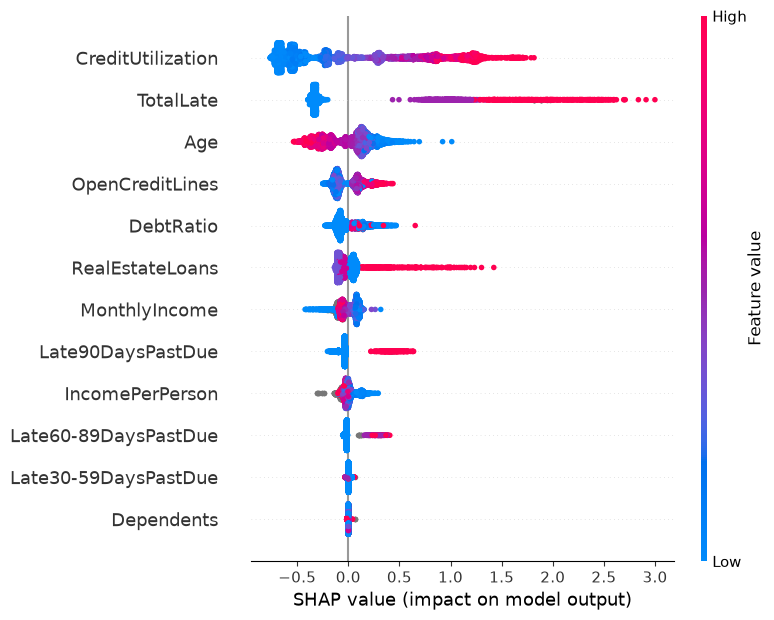

In [79]:
shap.summary_plot(
    shap_values,
    X_shap,
    show=True
)

### Individual Borrower Explanation

In [81]:
# Select one borrower from the validation set
sample_index = 0

sample = X_val.iloc[[sample_index]]

# Actual outcome
actual = y_val.iloc[sample_index]

# Predicted probability
predicted_probability = final_model.predict_proba(sample)[0, 1]

print("Actual Default:", actual)
print("Predicted Default Probability:", round(predicted_probability, 4))

Actual Default: 0
Predicted Default Probability: 0.0285


/Users/pushkarkamat/Desktop/Hybrid-Credit-Risk-Engine/.venv/lib/python3.14/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


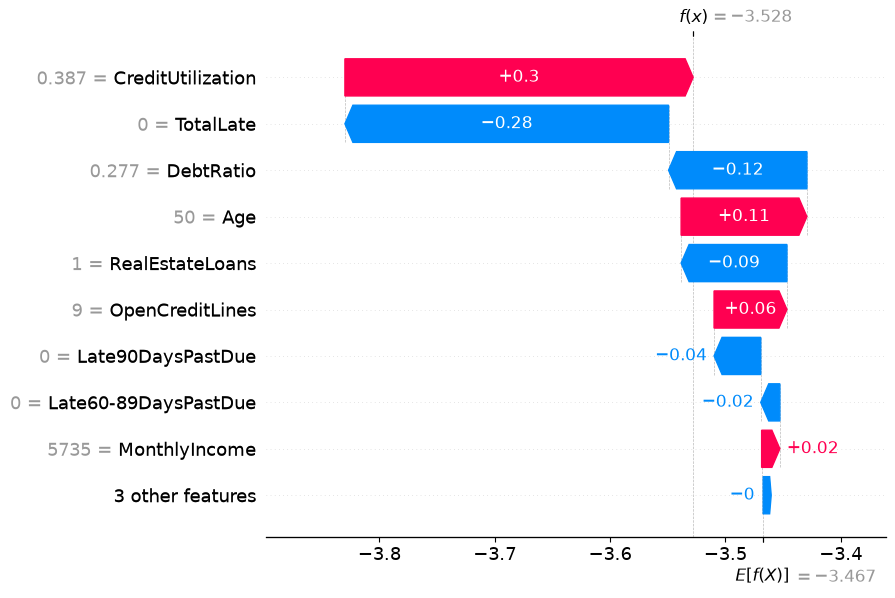

In [84]:
# Create SHAP values for the selected borrower
sample_shap_values = explainer.shap_values(sample)

if isinstance(sample_shap_values, list):
    sample_shap_values = sample_shap_values[1]

# Waterfall explanation

shap.waterfall_plot(
    shap.Explanation(
        values=sample_shap_values[0],
        base_values=explainer.expected_value[1]
            if isinstance(explainer.expected_value, (list, np.ndarray))
            else explainer.expected_value,
        data=sample.iloc[0],
        feature_names=sample.columns
    )
)

## Final Model Summary

In [90]:
from pprint import pprint

print("Final Credit Risk Model")
print("="*30)

summary = {

    "Model": {
        "Name": "LightGBM",
        "Number of Features": X.shape[1],
        "Best Iteration": final_model.best_iteration_,
        "Decision Threshold": best_threshold
    },

    "Hyperparameters": {
        "num_leaves": final_model.get_params()['num_leaves'],
        "learning_rate": final_model.get_params()['learning_rate'],
        "max_depth": final_model.get_params()['max_depth'],
        "min_child_samples": final_model.get_params()['min_child_samples'],
    },

    "Test Metrics": {
        "ROC-AUC": round(test_roc_auc, 4),
        "PR-AUC": round(test_pr_auc, 4),
        "Log Loss": round(test_logloss, 4),
        "Brier": round(test_brier, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1 Score": round(f1, 4),
        "Specificity": round(specificity, 4)
    }
}

pprint(summary, sort_dicts=False)

Final Credit Risk Model
{'Model': {'Name': 'LightGBM',
           'Number of Features': 12,
           'Best Iteration': 265,
           'Decision Threshold': np.float64(0.2)},
 'Hyperparameters': {'num_leaves': 7,
                     'learning_rate': 0.03,
                     'max_depth': 4,
                     'min_child_samples': 20},
 'Test Metrics': {'ROC-AUC': 0.872,
                  'PR-AUC': 0.4123,
                  'Log Loss': 0.1753,
                  'Brier': 0.0485,
                  'Precision': 0.3941,
                  'Recall': 0.51,
                  'F1 Score': 0.4446,
                  'Specificity': np.float64(0.9438)}}


## 15. Conclusion

The final LightGBM credit-risk model was developed using 12 features, including engineered features such as `TotalLate` and `IncomePerPerson`. The redundant `HasRealEstate` feature was removed because it provided no meaningful contribution to the model.

On the unseen test set, the model achieved a ROC-AUC of **0.8720** and a PR-AUC of **0.4123**. The model also achieved a Log Loss of **0.1753** and a Brier Score of **0.0485**, indicating that its predicted probabilities provide useful information about the relative risk of borrowers.

For classification, a decision threshold of **0.20** was selected using the validation set because it produced the highest F1 score among the tested thresholds. At this threshold, the final test results were:

- Precision: **39.41%**
- Recall: **51.00%**
- F1 Score: **44.46%**
- Specificity: **94.38%**
- Accuracy: **91.48%**

The choice of the 0.20 threshold reflects an important trade-off in credit-risk prediction. The model produces a probability of default for each borrower, but the threshold determines when that probability is converted into a "default risk" classification.

A **lower threshold** means that borrowers need less predicted risk to be flagged. This allows us to **catch more potential defaulters**, increasing recall, but it also causes more borrowers who would not actually default to be incorrectly flagged as risky, increasing false positives and lowering precision.

A **higher threshold** makes the model more selective. This can **increase precision**, meaning that a larger proportion of the borrowers flagged as risky may actually default. However, the model will also **miss more genuine defaulters**, increasing false negatives and reducing recall.

For example, on the validation set:

| Threshold | Precision | Recall | F1 |
|---:|---:|---:|---:|
| 0.10 | 28.27% | **68.55%** | 0.4003 |
| **0.20** | **39.59%** | **51.46%** | **0.4475** |
| 0.30 | 46.79% | 40.16% | 0.4322 |
| 0.50 | **59.72%** | 19.81% | 0.2976 |

This illustrates the trade-off clearly. At a threshold of 0.10, the model catches about **69% of actual defaulters**, but it also flags many non-defaulters incorrectly. At 0.50, precision rises to about **60%**, but recall falls to only about **20%**, meaning roughly 80% of actual defaulters are missed.

This trade-off is particularly important for a banking application. A false negative means that a borrower who eventually defaults was not identified as high risk. That can expose the bank to credit losses. Credit-risk management therefore focuses heavily on identifying and measuring the probability of default and potential credit losses; the Basel framework explicitly uses probability of default (PD) as a core credit-risk component, and expected loss calculations incorporate PD and loss given default. :contentReference[oaicite:0]{index=0}

At the same time, a bank cannot simply lower the threshold as much as possible. Doing so would identify more potential defaulters but could also result in a large number of genuine borrowers being rejected or sent for additional review. Therefore, the threshold should ultimately be chosen according to the **relative business cost of missing a defaulter versus incorrectly flagging a non-defaulter**. Banking guidance also emphasizes sound credit-granting, measurement, monitoring, and controls rather than relying on a single model metric. :contentReference[oaicite:1]{index=1}

For this project, **0.20 provides a reasonable balance between detecting defaulters and controlling false positives**, while maximizing F1 on the validation set.

Probability calibration was also tested. However, calibration increased both Log Loss and Brier Score, so the calibrated probabilities were not used in the final model. The original LightGBM probabilities were retained.

Finally, SHAP analysis provided interpretability for the model. `CreditUtilization`, `TotalLate`, `Age`, `OpenCreditLines`, and `DebtRatio` were among the most influential features. SHAP also allowed individual predictions to be explained by showing which borrower characteristics pushed a prediction toward higher or lower default risk.

Overall, the project demonstrates a complete credit-risk machine-learning workflow: **data cleaning, feature engineering, train-validation-test splitting, baseline comparison, LightGBM development, hyperparameter tuning, threshold selection, probability evaluation, calibration analysis, and model explainability.**

## Save Final Model

In [93]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

# Saving the final LightGBM Model
joblib.dump(
    final_model, '../models/credit_risk_lgbm.pkl'
)

# Saving the Decision Threshold Seperately
joblib.dump(
    best_threshold, '../models/credit_risk_threshold.pkl'
)

print("Final Model Saved Successfully")
print("Model path: '../models/credit_risk_lgbm.pkl' ")
print("Threshold:", best_threshold)

Final Model Saved Successfully
Model path: '../models/credit_risk_lgbm.pkl' 
Threshold: 0.2
